## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [1]:
!pip install -U ipykernel pandas scikit-learn matplotlib seaborn panda
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 19.1 MB/s  0:00:00eta 0:00:01
  Created wheel for panda: filename=panda-0.3.1-py3-none-any.whl size=7285 sha256=114d9933958e92d3babc9b42e9242469137cf8f46f51f4e29f26f5716e07bebb
  Stored in directory: /Users/david/Library/Caches/pip/wheels/df/5c/39/36f8dae25a1e88d6ec4411dec4a143781e64fdff6897758eec
Successfully built panda
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:━━━━━━━━━━━━━━━━━━ 0/3 [pandas]
      Successfully uninstalled pandas-2.3.3━ 0/3 [pandas]
  Attempting uninstall: ipykernel━━━━━━━━━━━━━━━ 0/3 [pandas]
    Found existing installation: ipykernel 7.1.0 0/3 [pandas]
    Uninstalling ipykernel-7.1.0:━━━━━━━━━━━ 0/3 [pandas]
      Successfully uninstalled ipykernel-7.1.00m━━━━━━━━━━━━━ 2/3 [ipykernel]
   ━━━━━━━━━━━━━━━━━━━━━━━━

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

In [2]:
df = pd.read_csv('data/golub.csv')

mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()

y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)

print(f'number of observations: {X.shape[0]}')
print(f'number of genes as predictors: {X.shape[1]}')


number of observations: 72
number of genes as predictors: 7129


/var/folders/tm/rcl9c7rx5_sd30ypm6jzq3g40000gn/T/ipykernel_23098/2036728920.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['outcome'] = df['cancer'].map(mapper)


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

The training MSE is basically zero, which means the linear model fits the training data almost perfectly. That is not too surprising here since there are way more gene predictors than actual patient observations, so a regular linear model has enough flexibility to pretty much memorize the data.

training MSE: 1.85694e-30


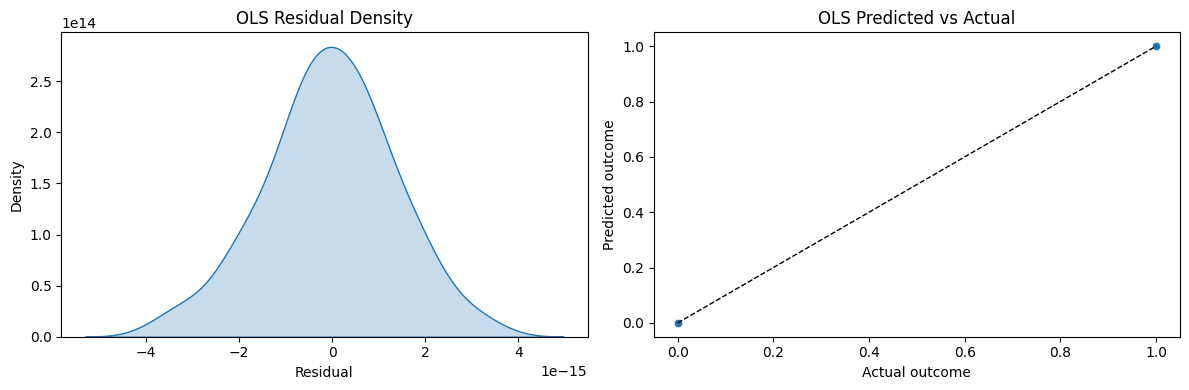

In [3]:
ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
residuals_ols = y_hat_ols - y

print(f'training MSE: {mse(y, y_hat_ols):.6g}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat_ols, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.tight_layout()
plt.show()



3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.


The difference between the almost-zero training error and the larger cross-validated MSE is a pretty classic sign of high variance. OLS has very low bias on the training data, but outside the sample it becomes a lot less stable because it is trying to fit thousands of genes with only 72 patients. So even though it looks like a perfect fit at first, cross validation shows that it does not actually generalize nearly as well as the training error makes it seem.

Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


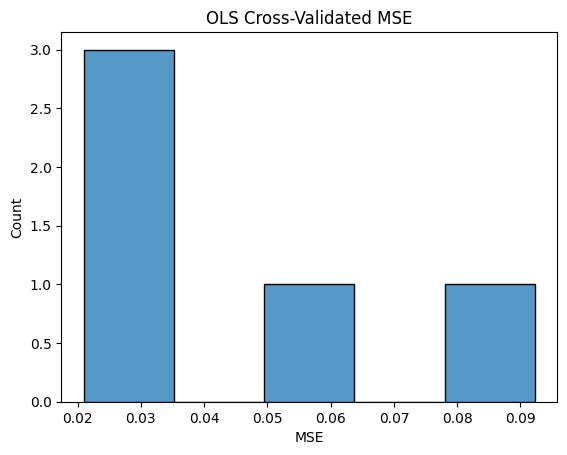

In [4]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores

print('Fold MSE values:', cv_mse)
print(f'Mean CV MSE: {cv_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(cv_mse):.6f}')
print(f'Standard deviation: {cv_mse.std():.6f}')

sns.histplot(cv_mse, bins=5)
plt.title('OLS Cross-Validated MSE')
plt.xlabel('MSE')
plt.show()



4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

In [8]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

alpha_grid = np.logspace(-4, -2, num=50)
lasso_cv = LassoCV(cv=10, alphas=alpha_grid, random_state=100, max_iter=10000)
lasso_cv.fit(X_sc, y)

alpha_star = lasso_cv.alpha_
mean_mse_path = np.mean(lasso_cv.mse_path_, axis=1)
index_star = np.argmin(mean_mse_path)

coefs = []
for alpha in lasso_cv.alphas_:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_sc, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

coefs_star = coefs[index_star]
selected_idx = np.nonzero(coefs_star)[0]
selected_genes = X.columns[selected_idx].tolist()

lasso_star = Lasso(alpha=alpha_star, max_iter=10000).fit(X_sc, y)
y_hat_lasso = lasso_star.predict(X_sc)

print(f'Optimal alpha: {alpha_star:.10f}')
print(f'Selected genes: {len(selected_genes)}')
print(f'Discarded genes: {X.shape[1] - len(selected_genes)}')
selected_genes


Optimal alpha: 0.0016768329
Selected genes: 70
Discarded genes: 7059


['AF000560_at',
 'AF006087_at',
 'D26579_at',
 'D29956_at',
 'D42043_at',
 'D50840_at',
 'D86982_at',
 'HG2161-HT2231_at',
 'J04101_at',
 'J04164_at',
 'L13278_at',
 'M17754_at',
 'M19507_at',
 'M20902_at',
 'M22960_at',
 'M23197_at',
 'M27819_at',
 'M27891_at',
 'M28713_at',
 'M31994_at',
 'M34344_at',
 'M63138_at',
 'M84526_at',
 'M95178_at',
 'M96326_rna1_at',
 'M98539_at',
 'U10868_at',
 'U14588_at',
 'U30828_at',
 'U34877_at',
 'U36621_cds2_at',
 'U46751_at',
 'U50136_rna1_at',
 'U51127_at',
 'U60062_at',
 'U82313_at',
 'U82759_at',
 'U89942_at',
 'X04143_at',
 'X14789_at',
 'X16706_at',
 'X53331_at',
 'X56741_at',
 'X63753_at',
 'X66533_at',
 'X69111_at',
 'X81479_at',
 'X83378_at',
 'X95735_at',
 'X96698_at',
 'Y07604_at',
 'Y07755_at',
 'Y10207_at',
 'Y12670_at',
 'M96843_at',
 'X58072_at',
 'AC002477_s_at',
 'L15326_s_at',
 'X57351_at',
 'U37055_rna1_s_at',
 'X07438_s_at',
 'M13690_s_at',
 'M26708_s_at',
 'M84371_rna1_s_at',
 'X12876_s_at',
 'U26312_s_at',
 'X85116_rna1_s_at',

The LASSO keeps 70 genes and discards 7,059 genes from the original 7,129 predictors. The selected genes are:

`AF000560_at`, `AF006087_at`, `D26579_at`, `D29956_at`, `D42043_at`, `D50840_at`, `D86982_at`, `HG2161-HT2231_at`, `J04101_at`, `J04164_at`, `L13278_at`, `M17754_at`, `M19507_at`, `M20902_at`, `M22960_at`, `M23197_at`, `M27819_at`, `M27891_at`, `M28713_at`, `M31994_at`, `M34344_at`, `M63138_at`, `M84526_at`, `M95178_at`, `M96326_rna1_at`, `M98539_at`, `U10868_at`, `U14588_at`, `U30828_at`, `U34877_at`, `U36621_cds2_at`, `U46751_at`, `U50136_rna1_at`, `U51127_at`, `U60062_at`, `U82313_at`, `U82759_at`, `U89942_at`, `X04143_at`, `X14789_at`, `X16706_at`, `X53331_at`, `X56741_at`, `X63753_at`, `X66533_at`, `X69111_at`, `X81479_at`, `X83378_at`, `X95735_at`, `X96698_at`, `Y07604_at`, `Y07755_at`, `Y10207_at`, `Y12670_at`, `M96843_at`, `X58072_at`, `AC002477_s_at`, `L15326_s_at`, `X57351_at`, `U37055_rna1_s_at`, `X07438_s_at`, `M13690_s_at`, `M26708_s_at`, `M84371_rna1_s_at`, `X12876_s_at`, `U26312_s_at`, `X85116_rna1_s_at`, `L08010_at`, `U84388_at`, `X06318_at`.


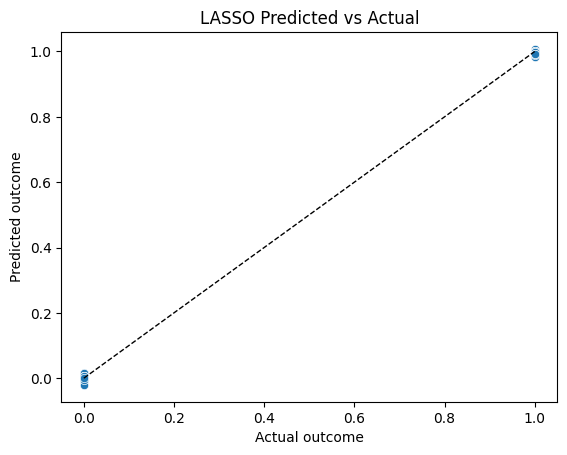

LASSO training MSE: 4.64279e-05


In [6]:
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
plt.title('LASSO Predicted vs Actual')
plt.xlabel('Actual outcome')
plt.ylabel('Predicted outcome')
plt.show()

print(f'LASSO training MSE: {mse(y, y_hat_lasso):.6g}')


5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

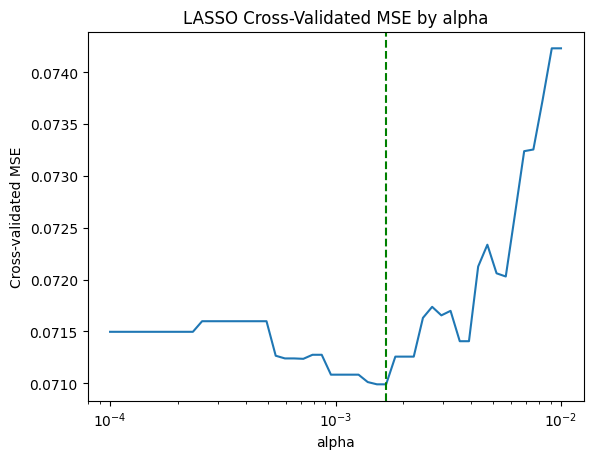

In [7]:
sns.lineplot(x=lasso_cv.alphas_, y=mean_mse_path)
plt.axvline(alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Cross-validated MSE')
plt.title('LASSO Cross-Validated MSE by alpha')
plt.show()

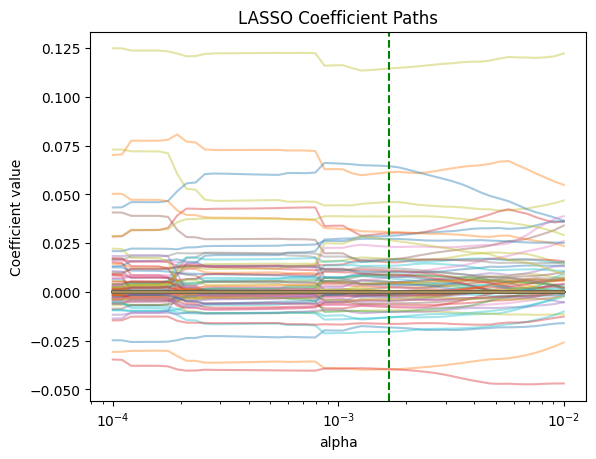

0.0016768329368110067


In [10]:
for i in range(coefs.shape[1]):
    plt.plot(lasso_cv.alphas_, coefs[:, i], alpha=0.4)
plt.xscale('log')
plt.axvline(alpha_star, color='green', linestyle='--')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.show()
print(alpha_star)

Large values of $\alpha$ on the left side of the plot produce too much shrinkage, which leads to the model underfitting there. On the other hand, very small values of $\alpha$ on the right side of the plot allow too many coefficients back into the model, so the model is overfitting there. The minimum expected error occurs at approximately $\alpha = 0.0016768329368110067$.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

OLS performs perfectly on the training set due to the high-dimensional setting with many more predictors than observations, making the model to more effectively memorize the sample. This flexibility drives the training error to zero, but also makes the fitted coefficients extremely sensitive to noise. On the other hand, The LASSO improves predictive performance through shrinking coefficients and setting many of them exactly to zero. Although bias rises a little, variance is reduced by a larger value. In this dataset, this trade-off is beneficial because only a relatively small subset of genes appears to carry most of the signal for separating ALL from AML.

7. Why do regularization methods lend themselves to scenarios like precision health? 

In this lab, we saw how overwhelming genomic data can be. There are thousands of genes in a human genome, and many of them interact in complicated and complex ways, making it unrealistic to include everything in our model. Regularization methods like LASSO help simplify this by narrowing the focus to a set of important genes. This decreases the amount of data. This helps us be more concise, including only the vital genetic information. In precision health, where decisions need to be both accurate and practical and with speed, this is extremely helpful. It also makes results easier to interpret, which is important when doctors need to explain findings to patients. This makes the doctors job easier and helps the patient understand more simple information. 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Although LASSO can point out important genes, LASSO still only makes predictions based on patterns and not causes. It doesn't tell us whether a gene actually causes a disease. This is a important limitation. Acting on something that is only correlated can lead to the wrong decisions and potentially harm patients when the relationship is not truly casual. A gene might look important in the model, but targeting it might not actually help the patient. Futhermore, another risk is that the model may miss important genes entirely if they don't stand out strongly in the data. As someone who wants to be doctor I have learned through shadowing that doing more is not always better in medicine. Doctors have to balance data with judgment for the good of the patient, as not everything we can predict is something we can fully understand.